In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('..'))

from src.data.loader import DataLoader
from src.models.supervised import FailurePredictor
from src.models.semi_supervised import SelfTrainingModule
from sklearn.metrics import f1_score

In [2]:
# Load dữ liệu
loader = DataLoader('../data/raw/ai4i2020.csv')
df = loader.load_data()
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Dùng class cũ để chia train/test chuẩn
predictor = FailurePredictor()
X_train, X_test, y_train, y_test = predictor.prepare_data(df)

# Reset index để tránh lỗi khi mask
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

print(f"Tổng tập train gốc: {len(X_train)}")

-> Đã load dữ liệu: (10000, 14)
Tổng tập train gốc: 8000


In [3]:
# Chỉ giữ lại 10% nhãn (Đây là kịch bản khó mà đề bài yêu cầu)
LABEL_RATIO = 0.1 
st_module = SelfTrainingModule()
y_train_masked = st_module.mask_labels(y_train, ratio=LABEL_RATIO)

print(f"Số lượng mẫu có nhãn ban đầu (10%): {sum(y_train_masked != -1)}")
print(f"Số lượng mẫu bị ẩn nhãn (90%): {sum(y_train_masked == -1)}")

Số lượng mẫu có nhãn ban đầu (10%): 800
Số lượng mẫu bị ẩn nhãn (90%): 7200


In [4]:
# Lọc ra chỉ lấy đúng 10% dữ liệu có nhãn để train
X_labeled_only = X_train[y_train_masked != -1]
y_labeled_only = y_train_masked[y_train_masked != -1]

model_sup = FailurePredictor()
model_sup.train(X_labeled_only, y_labeled_only)
y_pred_sup = model_sup.model.predict(X_test)
score_sup = f1_score(y_test, y_pred_sup)

print(f"F1-Score (Chỉ dùng 10% dữ liệu): {score_sup:.4f}")

-> Đang huấn luyện mô hình Random Forest...
F1-Score (Chỉ dùng 10% dữ liệu): 0.7965


In [5]:
# Chạy Self-training trên toàn bộ tập (bao gồm cả phần mất nhãn)
model_self = SelfTrainingModule(threshold=0.85, max_iter=5)
model_self.fit(X_train, y_train_masked)

y_pred_self = model_self.predict(X_test)
score_self = f1_score(y_test, y_pred_self)

print(f"F1-Score (Self-Training): {score_self:.4f}")

Bắt đầu Self-Training với 800 mẫu có nhãn...
Iter 1: Đã thêm 6941 nhãn giả (Pseudo-labels). Tổng mẫu train: 7741
Iter 2: Đã thêm 57 nhãn giả (Pseudo-labels). Tổng mẫu train: 7798
Iter 3: Đã thêm 9 nhãn giả (Pseudo-labels). Tổng mẫu train: 7807
Iter 4: Không tìm thấy nhãn giả nào đủ tin cậy.
-> Hoàn tất Self-Training.
F1-Score (Self-Training): 0.7857


C:\Users\Admin\AppData\Local\Temp\ipykernel_18604\2116040808.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=methods, y=scores, palette='magma')


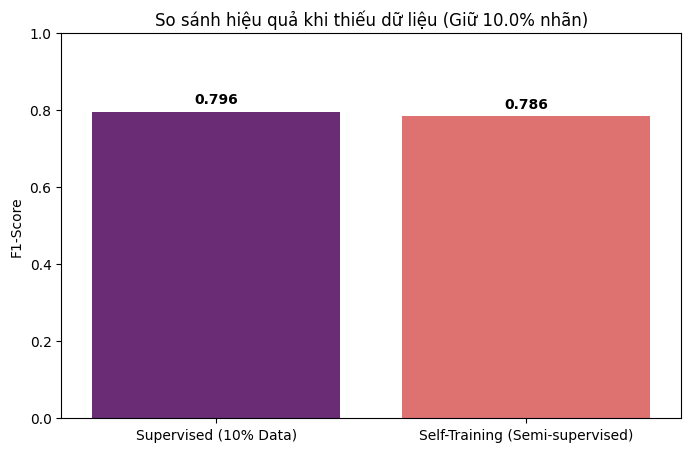

In [6]:
plt.figure(figsize=(8, 5))
methods = ['Supervised (10% Data)', 'Self-Training (Semi-supervised)']
scores = [score_sup, score_self]

sns.barplot(x=methods, y=scores, palette='magma')
plt.title(f"So sánh hiệu quả khi thiếu dữ liệu (Giữ {LABEL_RATIO*100}% nhãn)")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()